In [48]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
# Read data (only need n and d?)
support2 = pd.read_csv("../data/support2/real_support2_small.csv")
n,d = support2.shape

# Read regression coefficients from AIA game
regCoeff = pd.read_csv("../tests_support2_small/inference/reg_coeff_dict_keys(['totcst', 'crea']).csv")

In [50]:
regCoeff.columns # d regression coefficients per game and each synthetic data set per game (and for each combination of  sensitive attribute, target ID and genModel)

Index(['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10',
       'b11', 'b12', 'b13', 'b14', 'b15', 'b16', 'b17', 'b18', 'b19', 'b20',
       'b21', 'b22', 'b23', 'b24', 'b25', 'b26', 'sa', 'tid', 'genModel'],
      dtype='object')

In [51]:
regCoeff.sa.unique(), regCoeff.tid.unique(), regCoeff.genModel.unique()

(array(['totcst', 'crea'], dtype=object),
 array(['ID447', 'ID1124', 'ID84'], dtype=object),
 array(['IMRV(0.5)', 'CvineSensitive(5)', 'Cvine', 'PrivBayesEps0.1',
        'CTGAN', 'TVAE'], dtype=object))

In [52]:
sa = "totcst"
tid = "ID1124"
MAB = []
for gm in regCoeff.genModel.unique():
    print(gm)
    df = regCoeff.loc[(regCoeff["sa"]==sa) & (regCoeff["tid"] == tid) & (regCoeff["genModel"]==gm),]
    mab = df[df.columns[range(d)]].abs().sum().sum()/(d*df.shape[0])
    MAB.append(mab)

IMRV(0.5)
CvineSensitive(5)
Cvine
PrivBayesEps0.1
CTGAN
TVAE


In [53]:
df

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,b20,b21,b22,b23,b24,b25,b26,sa,tid,genModel
320,-1.100132e-16,0.007588,-0.081864,0.104761,-0.053150,0.032063,-0.015996,0.036749,0.163094,0.136826,...,-0.008468,0.010009,0.006069,-0.060373,0.429691,0.021296,0.004414,totcst,ID1124,TVAE
321,-5.193352e-18,0.007283,-0.069792,0.006105,0.048195,0.003442,-0.005939,0.056445,0.359228,0.088784,...,0.042608,0.026290,-0.085033,-0.055632,0.331361,-0.003944,-0.029311,totcst,ID1124,TVAE
322,-7.464668e-17,-0.051870,-0.059069,0.078164,-0.007416,0.040163,0.005370,-0.034579,0.207112,0.024837,...,0.017835,-0.020836,-0.071620,-0.070842,0.238619,0.040488,0.029417,totcst,ID1124,TVAE
323,5.119423e-17,-0.023148,-0.030629,0.092260,-0.011851,0.033762,0.024670,-0.028046,0.157522,0.118577,...,-0.061012,-0.144971,0.098943,-0.051877,0.358099,0.053063,-0.105903,totcst,ID1124,TVAE
324,-2.916250e-17,-0.028175,-0.084957,0.113874,0.016513,-0.011417,-0.025390,0.086962,0.192473,0.066944,...,0.000287,-0.044992,-0.032613,0.005765,0.243758,-0.036827,0.005070,totcst,ID1124,TVAE
325,-4.451849e-17,0.010943,-0.081703,0.036142,-0.076672,0.002887,0.011715,0.062221,0.114622,0.176106,...,-0.034583,-0.139810,-0.048646,-0.067236,0.416274,0.000440,0.050298,totcst,ID1124,TVAE
326,-1.054962e-16,-0.095187,-0.036138,0.015461,0.044241,-0.005340,0.020017,0.117523,0.158564,0.071415,...,-0.018830,-0.059180,-0.081688,-0.012499,0.358105,0.010556,-0.042568,totcst,ID1124,TVAE
327,9.722699e-17,-0.028477,-0.012619,0.070596,0.025119,0.036967,0.044424,0.049658,0.121867,0.052021,...,-0.005819,-0.030316,-0.030633,0.000940,0.340562,-0.025488,0.048873,totcst,ID1124,TVAE
328,5.512916e-17,0.040056,0.021309,0.095295,0.008846,-0.011946,0.008232,0.030444,0.200041,0.120221,...,-0.051901,-0.042130,-0.008560,-0.012707,0.398275,0.002587,-0.125883,totcst,ID1124,TVAE
329,-4.725357e-17,-0.046160,-0.028512,0.115755,-0.040906,-0.030224,-0.003313,0.020541,0.108665,0.120807,...,-0.064073,-0.120539,-0.048348,-0.015330,0.251209,-0.015176,-0.049104,totcst,ID1124,TVAE


In [54]:
# Calculate MAB ...

Text(0, 0.5, 'MAB_totcst')

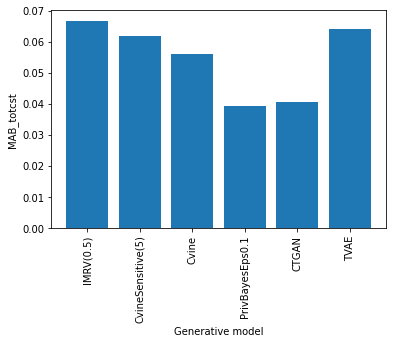

In [57]:
plt.bar(regCoeff.genModel.unique(), MAB)
plt.xticks(rotation=90)
plt.xlabel("Generative model")
plt.ylabel(rf"MAB_{sa}")